# Preprocessing Lung Sounds

In [1]:
import os
import sys
# Add the parent directory to the Python path to allow module imports
sys.path.append(os.path.dirname(os.getcwd()))

# Set random seed for reproducibility
SEED = 42
import random
random.seed(SEED)

import librosa
from matplotlib import pyplot as plt

from modules.dataset import ICBHIAudioDataset, KAUHAudioDataset, CombinedAudioDataset, LungSoundAudioDataset
from modules.transforms import *

# NOTE: Some classes have very few samples, so we will focus on a subset of classes for the analysis.
SELECTED_CLASSES = [
    "Asthma",
    "Bronchiectasis",
    "Bronchiolitis",
    # "Bronchitis",
    "COPD",
    "Healthy",
    # "Heart Failure",
    # "LRTI",
    "Lung Fibrosis",
    # "Pleural Effusion",
    "Pneumonia",
    "URTI",
]

In [2]:
DATA_FOLDER = os.path.join(os.path.dirname(os.getcwd()), "data/data_raw")
if not os.path.exists(DATA_FOLDER):
    print(f"Data directory not found at {DATA_FOLDER}. Please ensure the data is downloaded and placed in the correct location.")

In [22]:
TARGET_SR = 22050       # Hz
TARGET_DURATION = 5.0   # seconds

def preprocess_audio(audio: LungSoundAudio) -> LungSoundAudio:
    # 1. Resample the audio to the target sampling rate
    audio = Resample(target_sr=TARGET_SR)(audio)
    # 2. Pad or trim the audio to the target duration
    audio = PadOrTrim(target_duration=TARGET_DURATION)(audio)
    # 3. Normalize the audio to have zero mean and unit variance
    audio = NormalizeAudio()(audio)
    return audio

def get_samples_by_label(dataset: LungSoundAudioDataset) -> dict:
    """
    Get one sample for each label in the dataset.
    Args:
        dataset (LungSoundDataset): The dataset to sample from.
    Returns:
        dict: A dictionary mapping each label to a random sample index.
    """
    data = dataset.data
    samples = {}
    for label in sorted(data["Diagnosis"].unique()):
        label_samples = data[data["Diagnosis"] == label]
        random_idx = random.choice(label_samples.index.tolist())
        samples[label] = random_idx
    return samples

def plot_features_by_label(dataset: LungSoundAudioDataset, samples: dict | None = None, preprocess: bool = True) -> None:
    if samples is None:
        samples = get_samples_by_label(dataset)
        print("Sampled records:")
        print("----------------")
        for label, sample in samples.items():
            print(f"Class: {label}, idx: {sample}")
        print("----------------")

    feature_extractors = [
        STFT(n_fft=2048, hop_length=512),
        MelSpectrogram(n_fft=2048, hop_length=512, n_mels=128),
        MFCC(n_fft=2048, hop_length=512, n_mfcc=128),
        MFCCDelta(n_fft=2048, hop_length=512, n_mfcc=128),
        Chroma(n_fft=2048, hop_length=512, n_chroma=128),
        SpectralContrast(n_bands=4, fmin=50),
        CQT(n_bins=48, fmin=30, bins_per_octave=12),
        Phase(),
    ]

    for extractor in feature_extractors:
        num_classes = len(samples)
        num_rows = (num_classes + 3) // 4
        num_cols = min(num_classes, 4)
        figure, axes = plt.subplots(num_rows, num_cols, figsize=(4 * num_cols, 3 * num_rows))
        axes = axes.flatten()

        extractor_name = extractor.__class__.__name__
        params = extractor.plot_params

        for i, (label, idx) in enumerate(samples.items()):
            ax = axes[i]
            sample, _ = dataset[idx]
            sample = preprocess_audio(sample) if preprocess else sample
            sample_transformed = extractor(sample)
            img = librosa.display.specshow(sample_transformed, ax=ax, **params)
            plt.colorbar(img, ax=ax)
            print(f"Sample shape for {extractor_name}: {sample_transformed.shape}")
        figure.suptitle(f"{extractor_name}")
        plt.tight_layout()
        plt.show()

Sampled records:
----------------
Class: Asthma, idx: 1009
Class: Bronchiectasis, idx: 483
Class: Bronchiolitis, idx: 433
Class: COPD, idx: 900
Class: Healthy, idx: 1062
Class: Lung Fibrosis, idx: 937
Class: Pneumonia, idx: 93
Class: URTI, idx: 474
----------------
Sample shape for STFT: (1025, 155)
Sample shape for STFT: (1025, 1723)
Sample shape for STFT: (1025, 1723)
Sample shape for STFT: (1025, 1723)
Sample shape for STFT: (1025, 206)
Sample shape for STFT: (1025, 89)
Sample shape for STFT: (1025, 1723)
Sample shape for STFT: (1025, 1723)


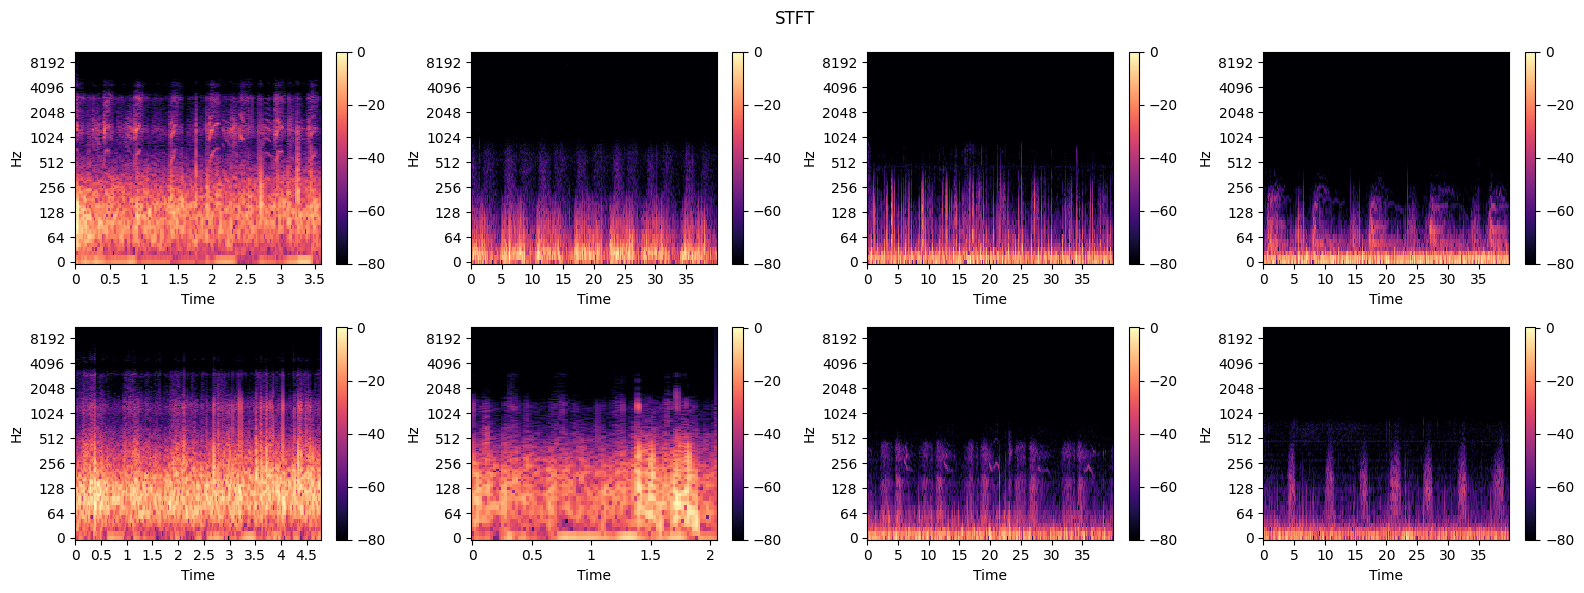

Sample shape for MelSpectrogram: (128, 155)
Sample shape for MelSpectrogram: (128, 1723)
Sample shape for MelSpectrogram: (128, 1723)
Sample shape for MelSpectrogram: (128, 1723)
Sample shape for MelSpectrogram: (128, 206)
Sample shape for MelSpectrogram: (128, 89)
Sample shape for MelSpectrogram: (128, 1723)
Sample shape for MelSpectrogram: (128, 1723)


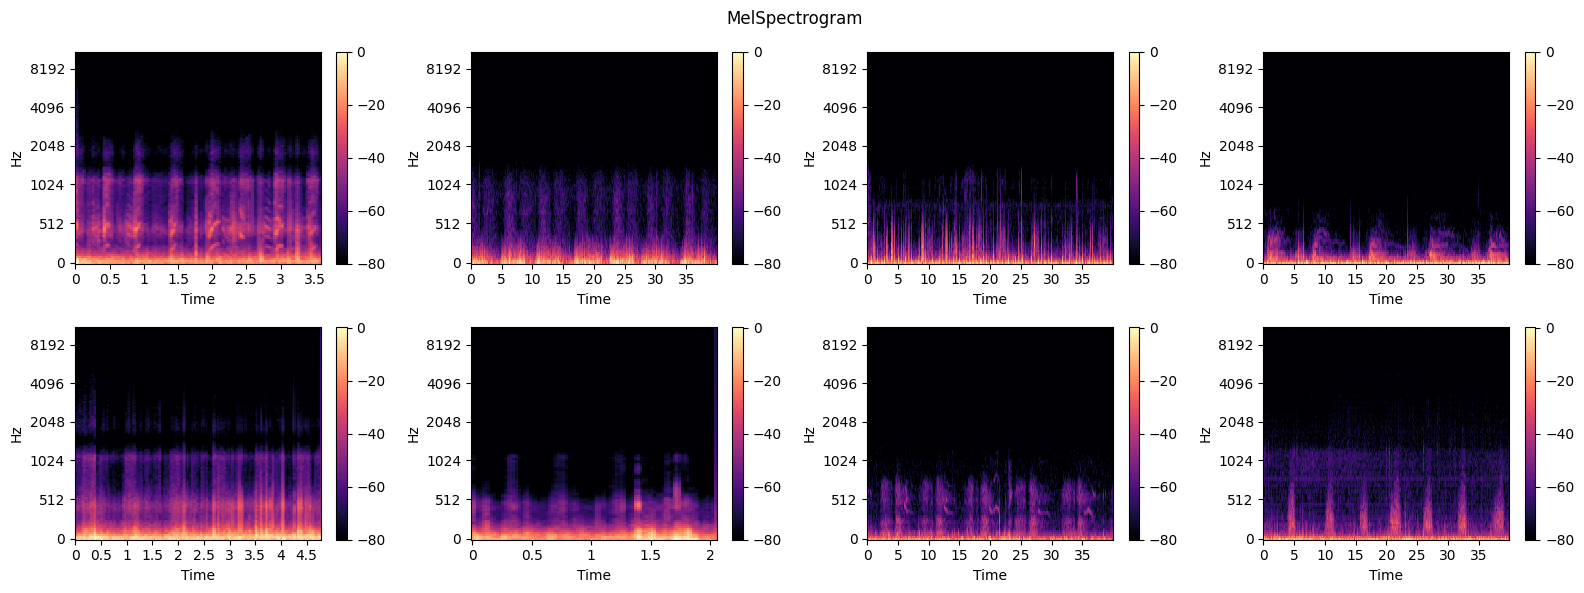

Sample shape for MFCC: (128, 155)
Sample shape for MFCC: (128, 1723)
Sample shape for MFCC: (128, 1723)
Sample shape for MFCC: (128, 1723)
Sample shape for MFCC: (128, 206)
Sample shape for MFCC: (128, 89)
Sample shape for MFCC: (128, 1723)
Sample shape for MFCC: (128, 1723)


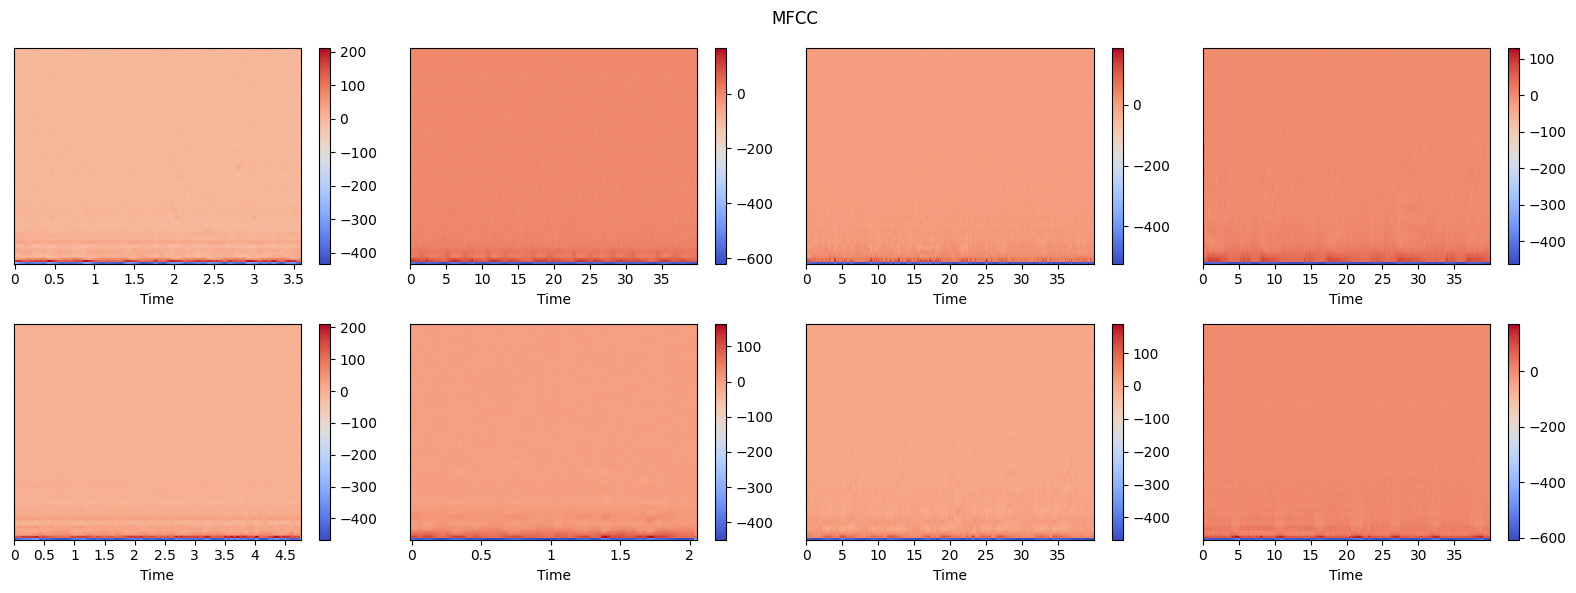

Sample shape for MFCCDelta: (128, 155)
Sample shape for MFCCDelta: (128, 1723)
Sample shape for MFCCDelta: (128, 1723)
Sample shape for MFCCDelta: (128, 1723)
Sample shape for MFCCDelta: (128, 206)
Sample shape for MFCCDelta: (128, 89)
Sample shape for MFCCDelta: (128, 1723)
Sample shape for MFCCDelta: (128, 1723)


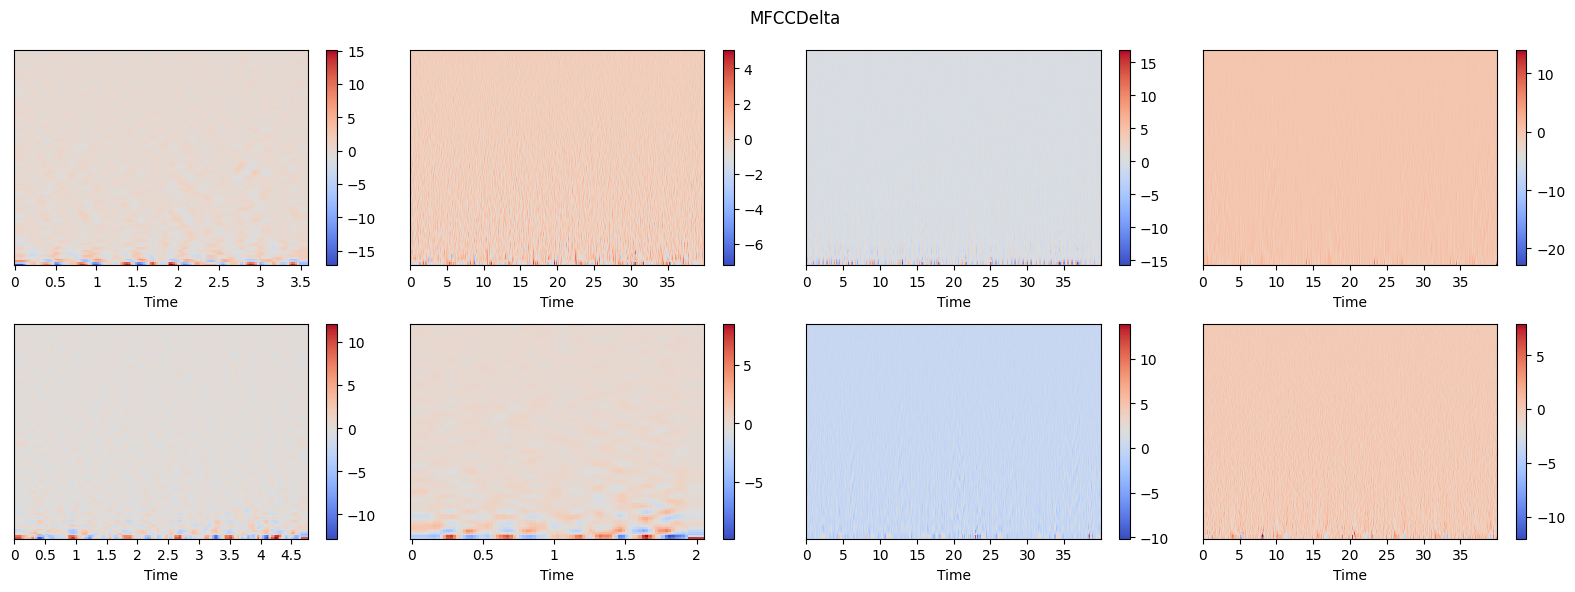

Sample shape for Chroma: (128, 155)
Sample shape for Chroma: (128, 1723)
Sample shape for Chroma: (128, 1723)
Sample shape for Chroma: (128, 1723)
Sample shape for Chroma: (128, 206)
Sample shape for Chroma: (128, 89)


/home/leticialopes/miniconda3/envs/lung_sounds/lib/python3.13/site-packages/librosa/core/pitch.py:103: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(


Sample shape for Chroma: (128, 1723)
Sample shape for Chroma: (128, 1723)


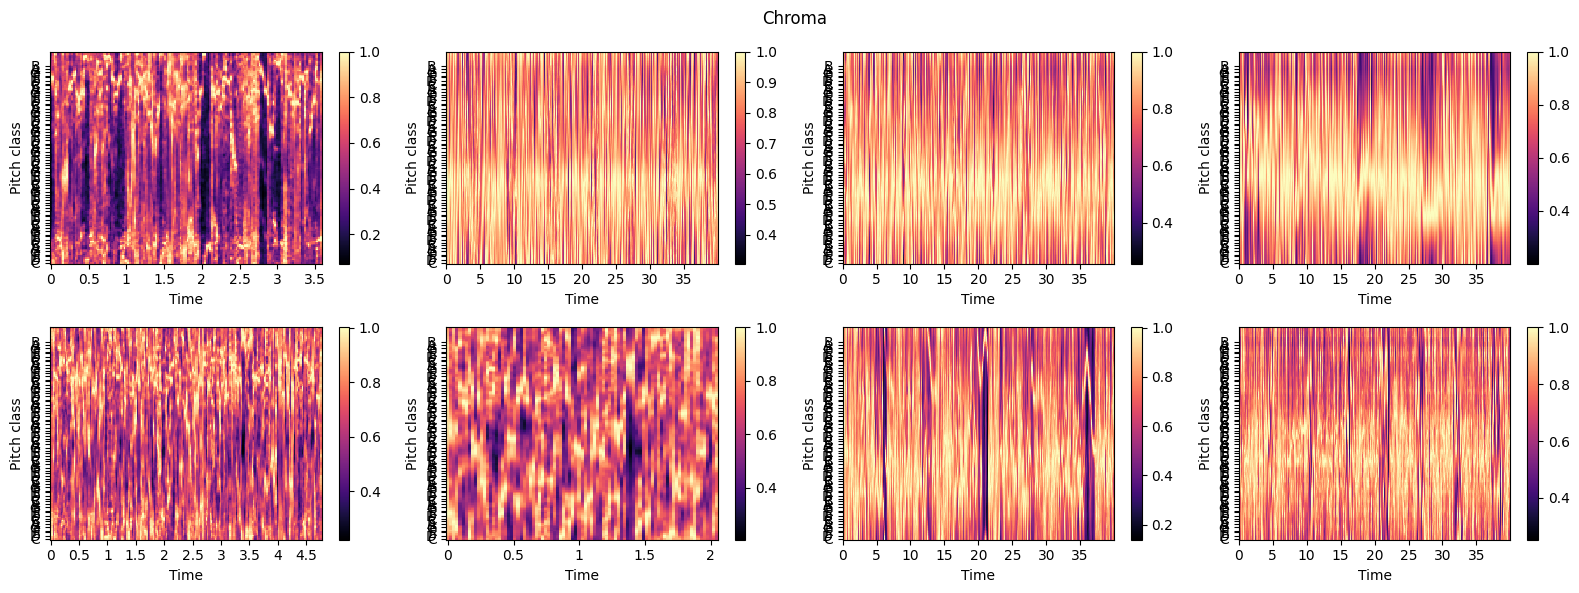

Sample shape for SpectralContrast: (5, 155)
Sample shape for SpectralContrast: (5, 1723)
Sample shape for SpectralContrast: (5, 1723)
Sample shape for SpectralContrast: (5, 1723)
Sample shape for SpectralContrast: (5, 206)
Sample shape for SpectralContrast: (5, 89)
Sample shape for SpectralContrast: (5, 1723)
Sample shape for SpectralContrast: (5, 1723)


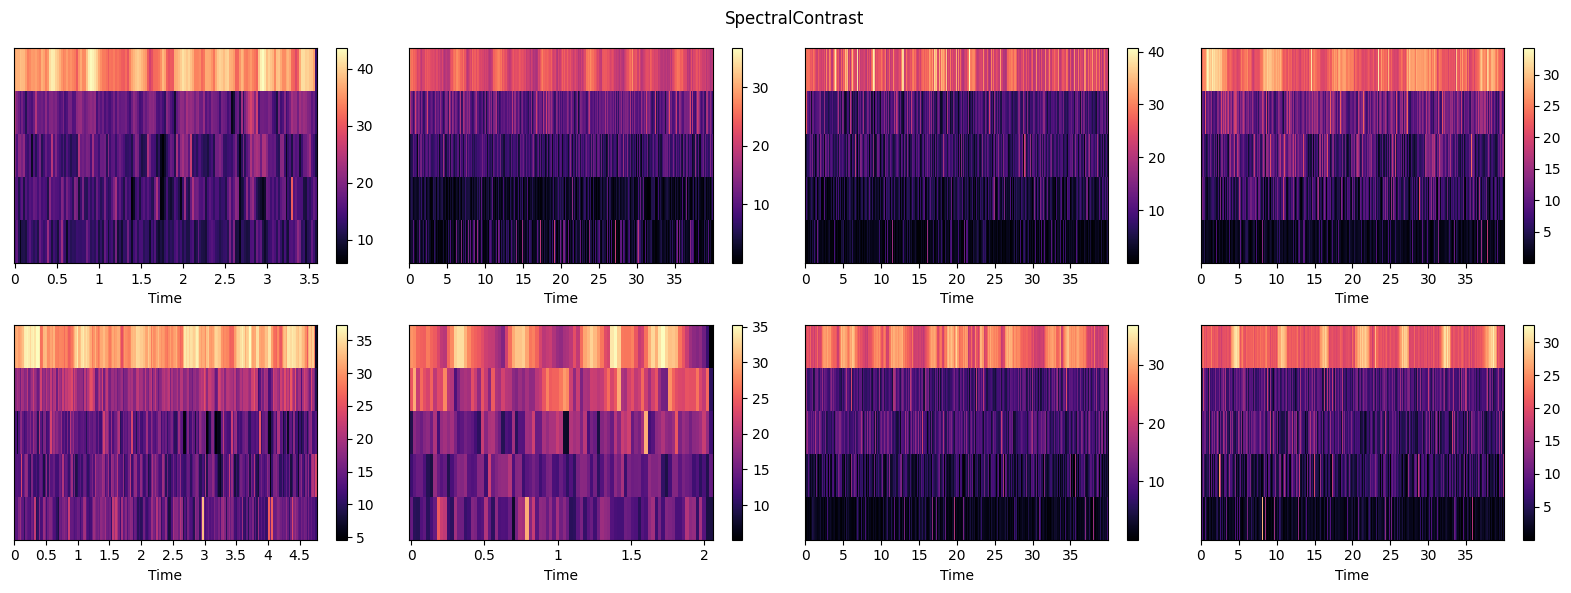

Sample shape for CQT: (48, 155)
Sample shape for CQT: (48, 1723)
Sample shape for CQT: (48, 1723)
Sample shape for CQT: (48, 1723)
Sample shape for CQT: (48, 206)
Sample shape for CQT: (48, 89)
Sample shape for CQT: (48, 1723)
Sample shape for CQT: (48, 1723)


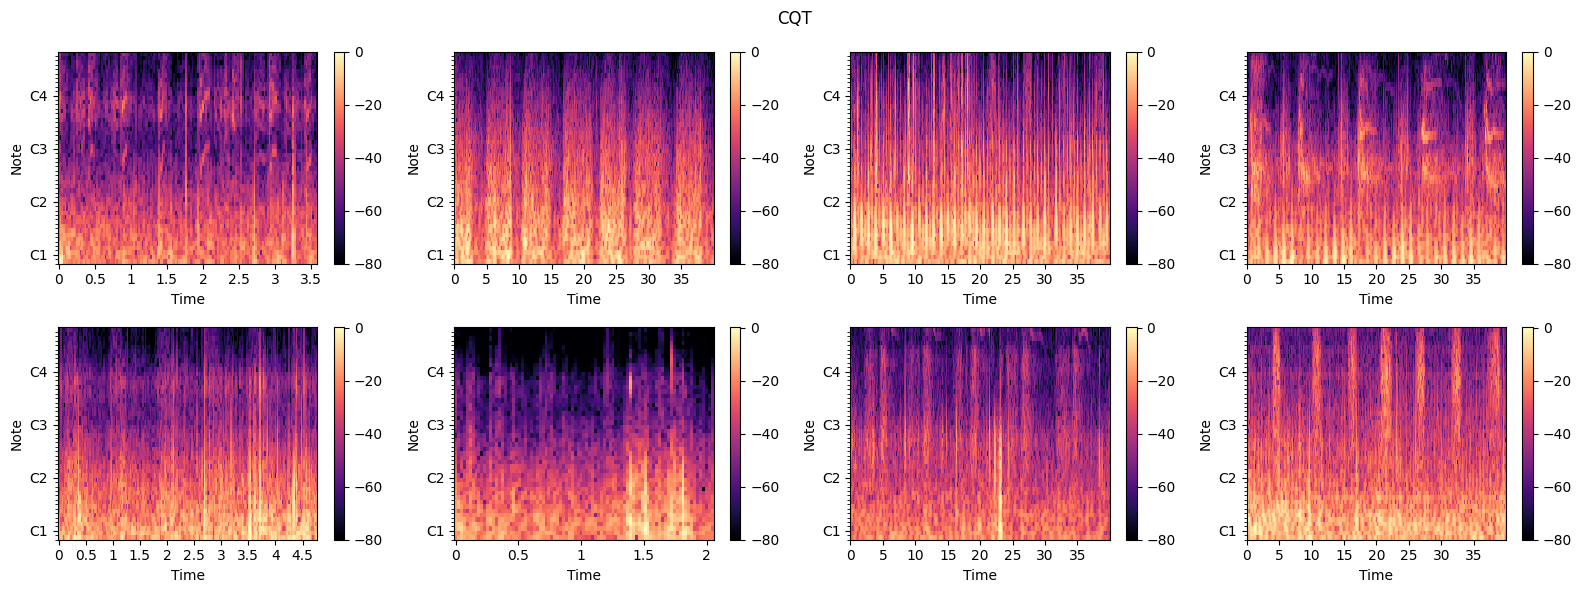

Sample shape for Phase: (1025, 155)
Sample shape for Phase: (1025, 1723)
Sample shape for Phase: (1025, 1723)
Sample shape for Phase: (1025, 1723)
Sample shape for Phase: (1025, 206)
Sample shape for Phase: (1025, 89)
Sample shape for Phase: (1025, 1723)
Sample shape for Phase: (1025, 1723)


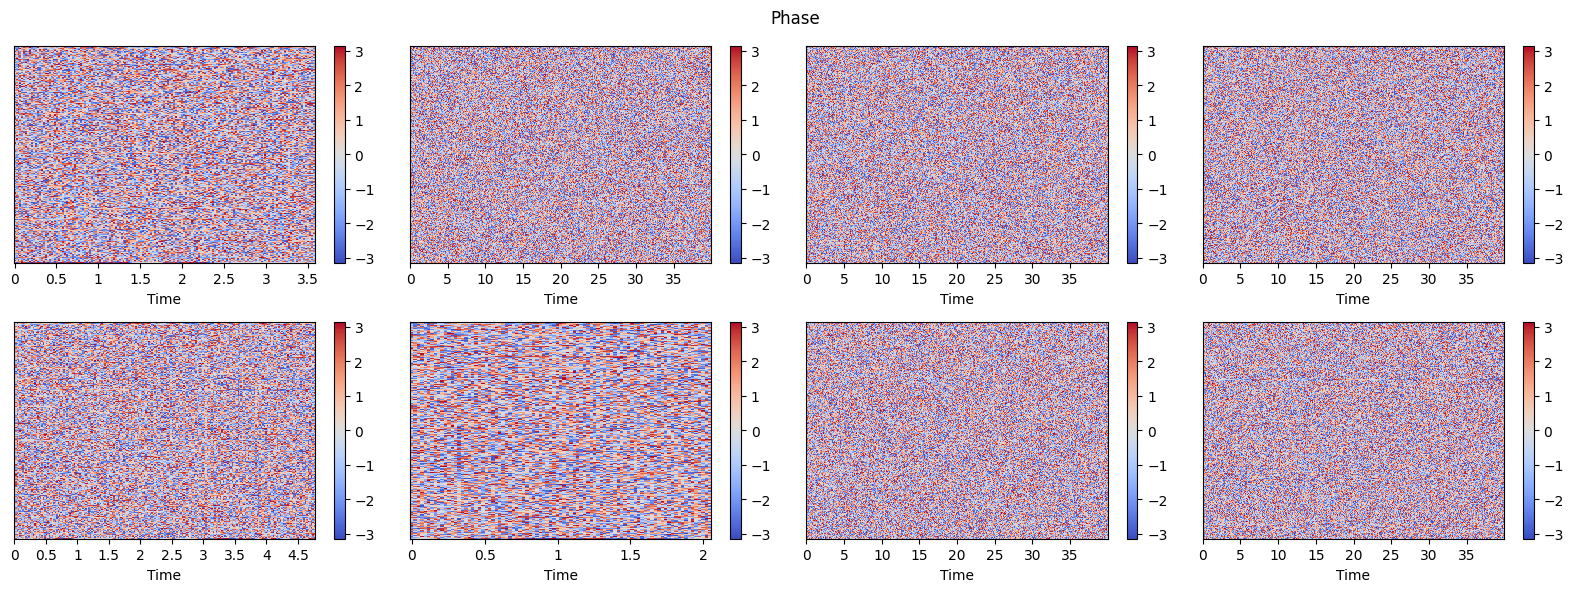

In [18]:
dataset = CombinedAudioDataset(DATA_FOLDER, "all", classes=SELECTED_CLASSES)
plot_features_by_label(dataset, preprocess=False)

Sampled records:
----------------
Class: Asthma, idx: 1110
Class: Bronchiectasis, idx: 485
Class: Bronchiolitis, idx: 873
Class: COPD, idx: 81
Class: Healthy, idx: 334
Class: Lung Fibrosis, idx: 1109
Class: Pneumonia, idx: 207
Class: URTI, idx: 305
----------------
Sample shape for STFT: (1025, 216)
Sample shape for STFT: (1025, 216)
Sample shape for STFT: (1025, 216)
Sample shape for STFT: (1025, 216)
Sample shape for STFT: (1025, 216)
Sample shape for STFT: (1025, 216)
Sample shape for STFT: (1025, 216)
Sample shape for STFT: (1025, 216)


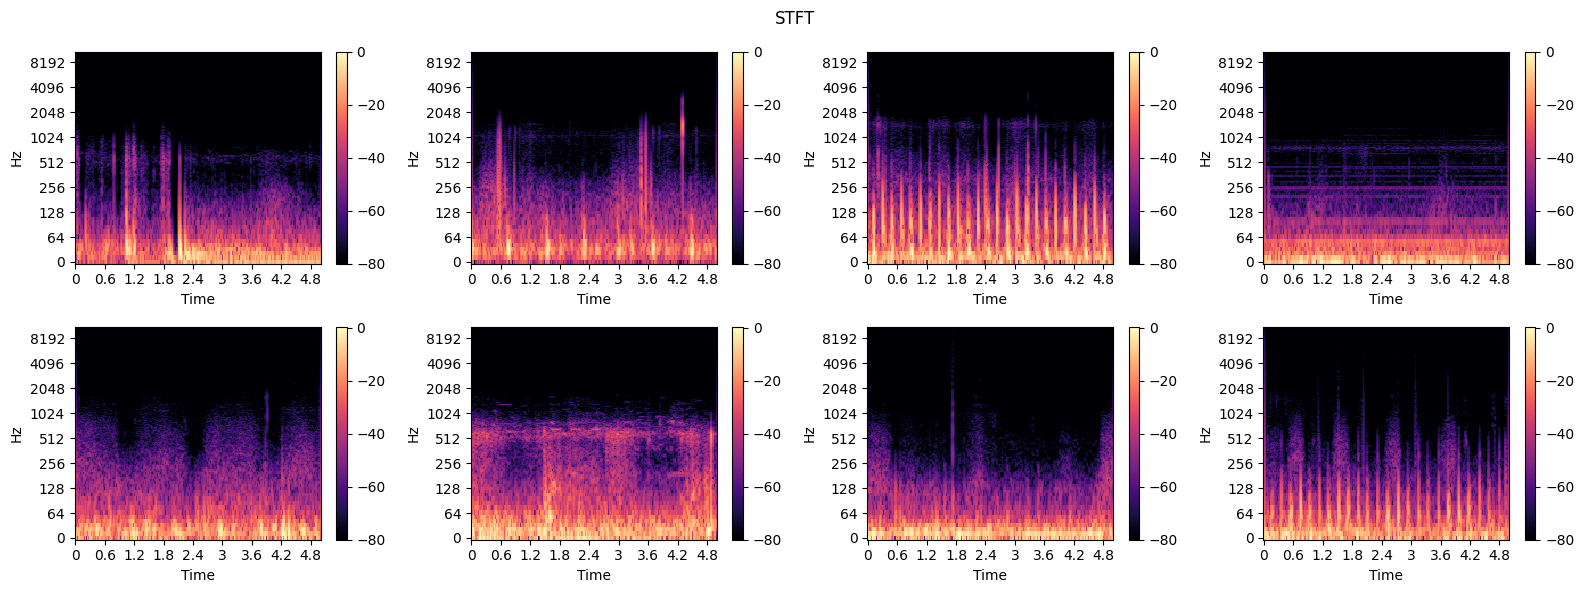

Sample shape for MelSpectrogram: (128, 216)
Sample shape for MelSpectrogram: (128, 216)
Sample shape for MelSpectrogram: (128, 216)
Sample shape for MelSpectrogram: (128, 216)
Sample shape for MelSpectrogram: (128, 216)
Sample shape for MelSpectrogram: (128, 216)
Sample shape for MelSpectrogram: (128, 216)
Sample shape for MelSpectrogram: (128, 216)


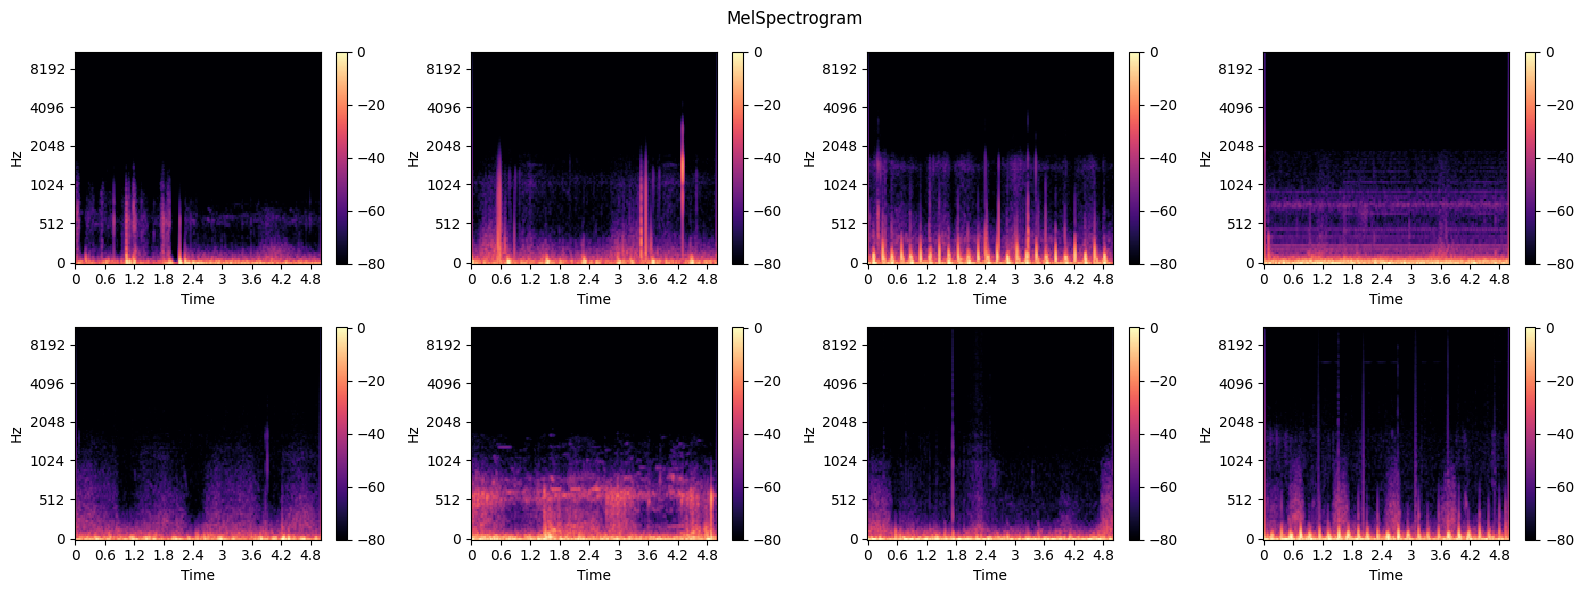

Sample shape for MFCC: (128, 216)
Sample shape for MFCC: (128, 216)
Sample shape for MFCC: (128, 216)
Sample shape for MFCC: (128, 216)
Sample shape for MFCC: (128, 216)
Sample shape for MFCC: (128, 216)
Sample shape for MFCC: (128, 216)
Sample shape for MFCC: (128, 216)


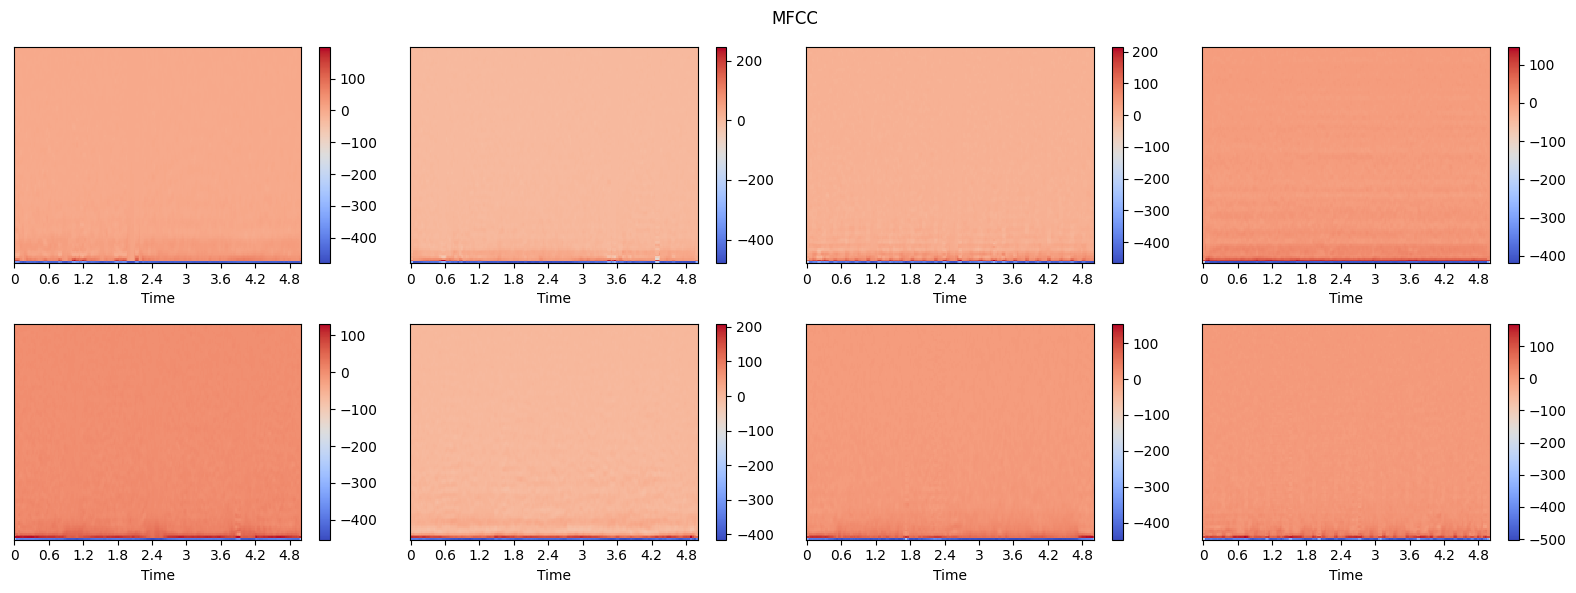

Sample shape for MFCCDelta: (128, 216)
Sample shape for MFCCDelta: (128, 216)
Sample shape for MFCCDelta: (128, 216)
Sample shape for MFCCDelta: (128, 216)
Sample shape for MFCCDelta: (128, 216)
Sample shape for MFCCDelta: (128, 216)
Sample shape for MFCCDelta: (128, 216)
Sample shape for MFCCDelta: (128, 216)


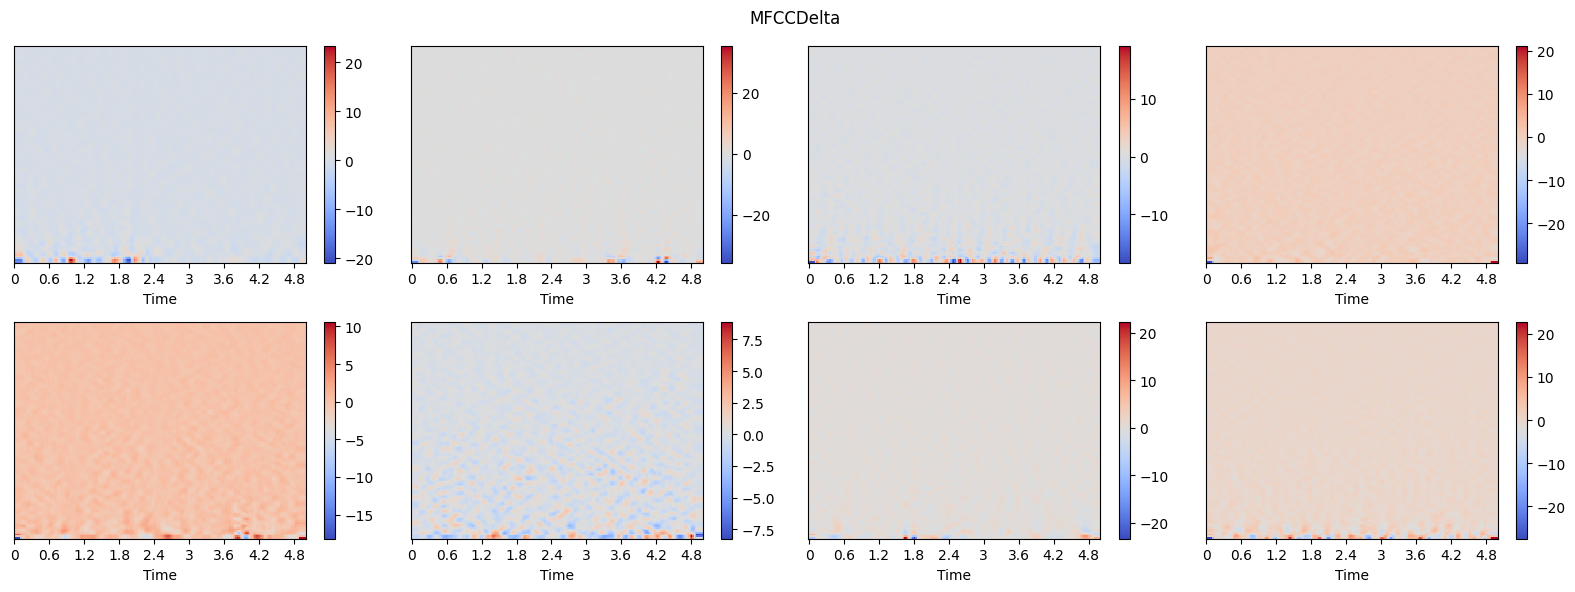

Sample shape for Chroma: (128, 216)
Sample shape for Chroma: (128, 216)
Sample shape for Chroma: (128, 216)
Sample shape for Chroma: (128, 216)


/home/leticialopes/miniconda3/envs/lung_sounds/lib/python3.13/site-packages/librosa/core/pitch.py:103: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(


Sample shape for Chroma: (128, 216)
Sample shape for Chroma: (128, 216)
Sample shape for Chroma: (128, 216)
Sample shape for Chroma: (128, 216)


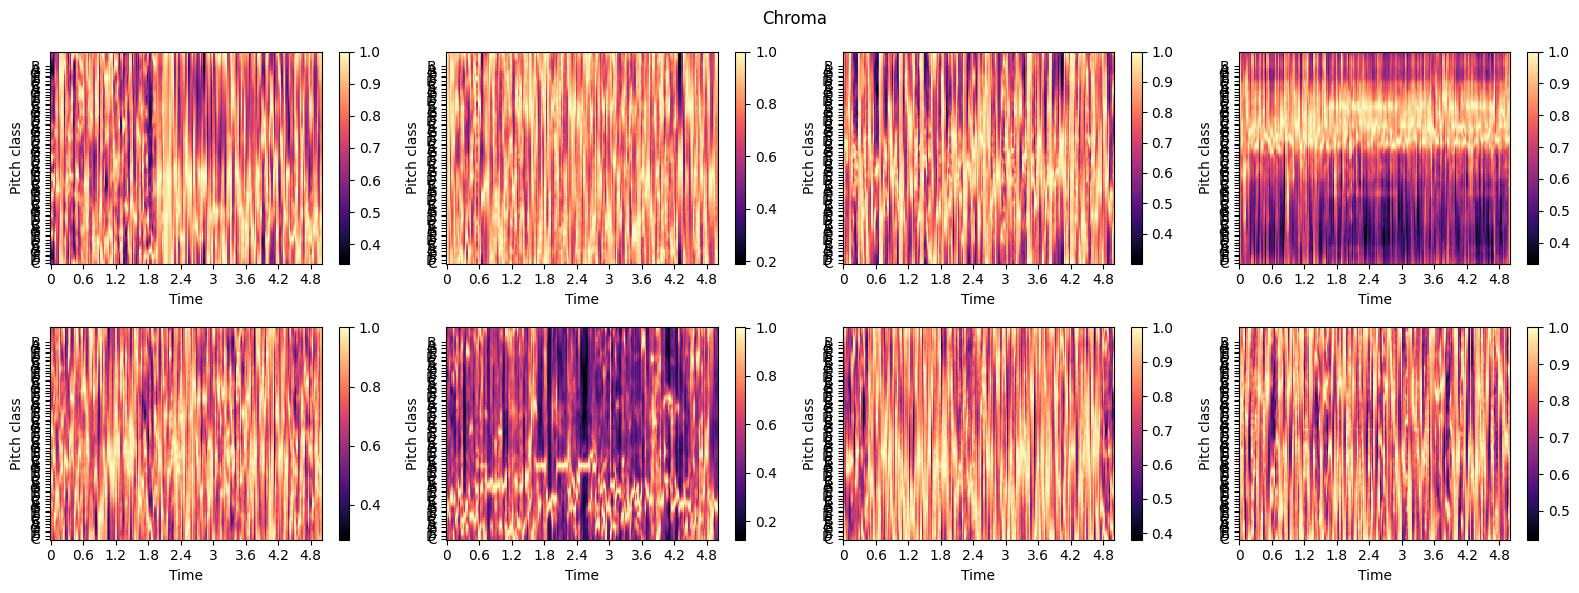

Sample shape for SpectralContrast: (5, 216)
Sample shape for SpectralContrast: (5, 216)
Sample shape for SpectralContrast: (5, 216)
Sample shape for SpectralContrast: (5, 216)
Sample shape for SpectralContrast: (5, 216)
Sample shape for SpectralContrast: (5, 216)
Sample shape for SpectralContrast: (5, 216)
Sample shape for SpectralContrast: (5, 216)


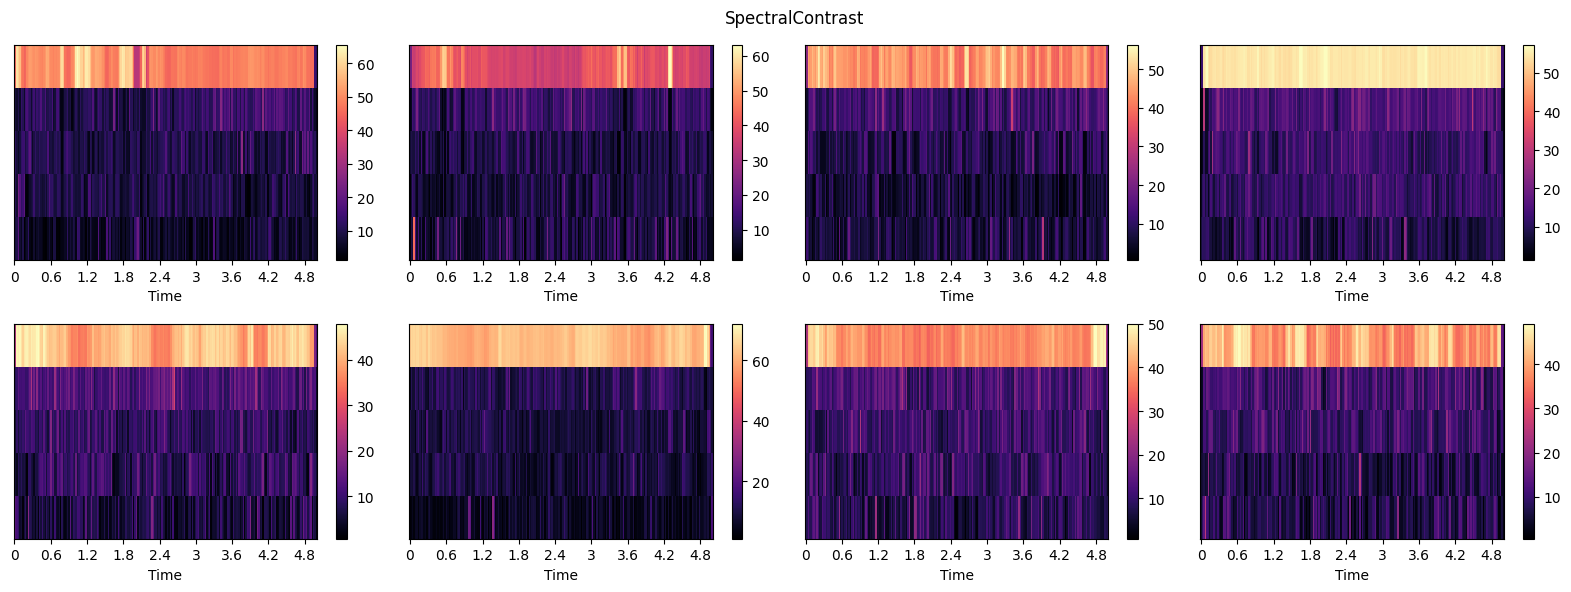

Sample shape for CQT: (48, 216)
Sample shape for CQT: (48, 216)
Sample shape for CQT: (48, 216)
Sample shape for CQT: (48, 216)
Sample shape for CQT: (48, 216)
Sample shape for CQT: (48, 216)
Sample shape for CQT: (48, 216)
Sample shape for CQT: (48, 216)


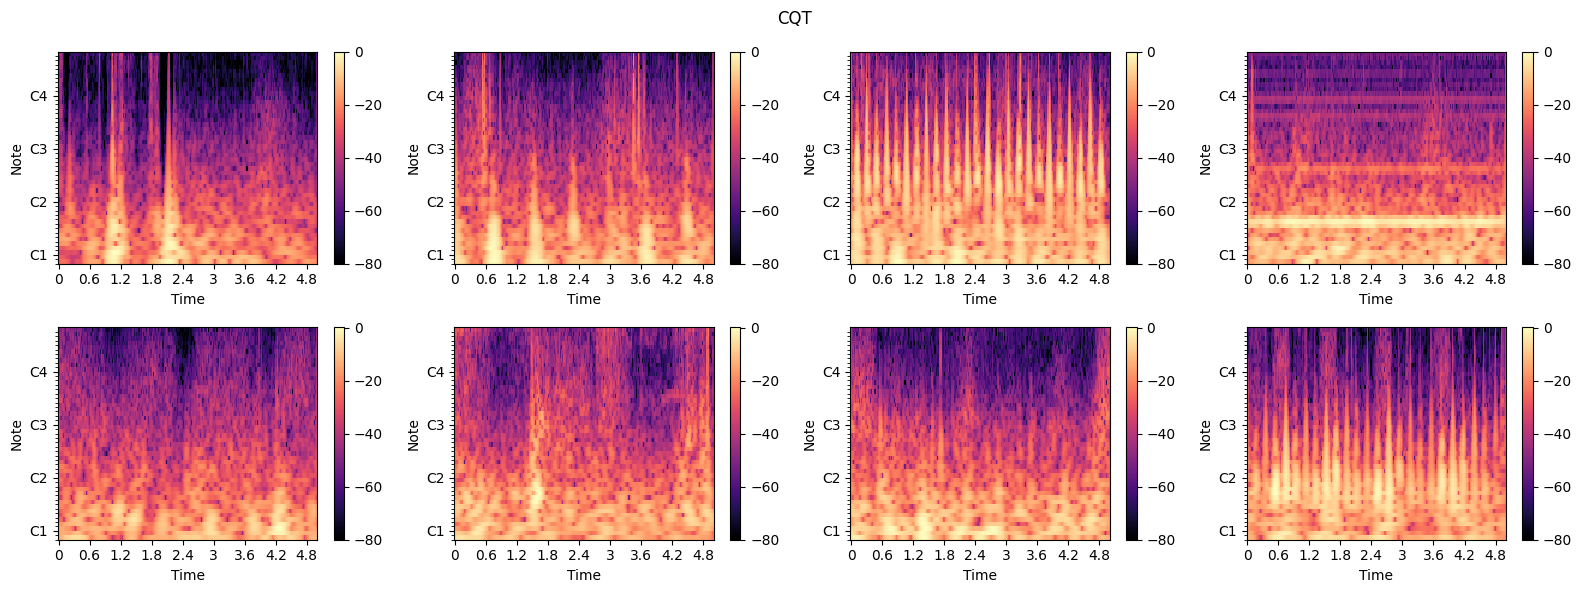

Sample shape for Phase: (1025, 216)
Sample shape for Phase: (1025, 216)
Sample shape for Phase: (1025, 216)
Sample shape for Phase: (1025, 216)
Sample shape for Phase: (1025, 216)
Sample shape for Phase: (1025, 216)
Sample shape for Phase: (1025, 216)
Sample shape for Phase: (1025, 216)


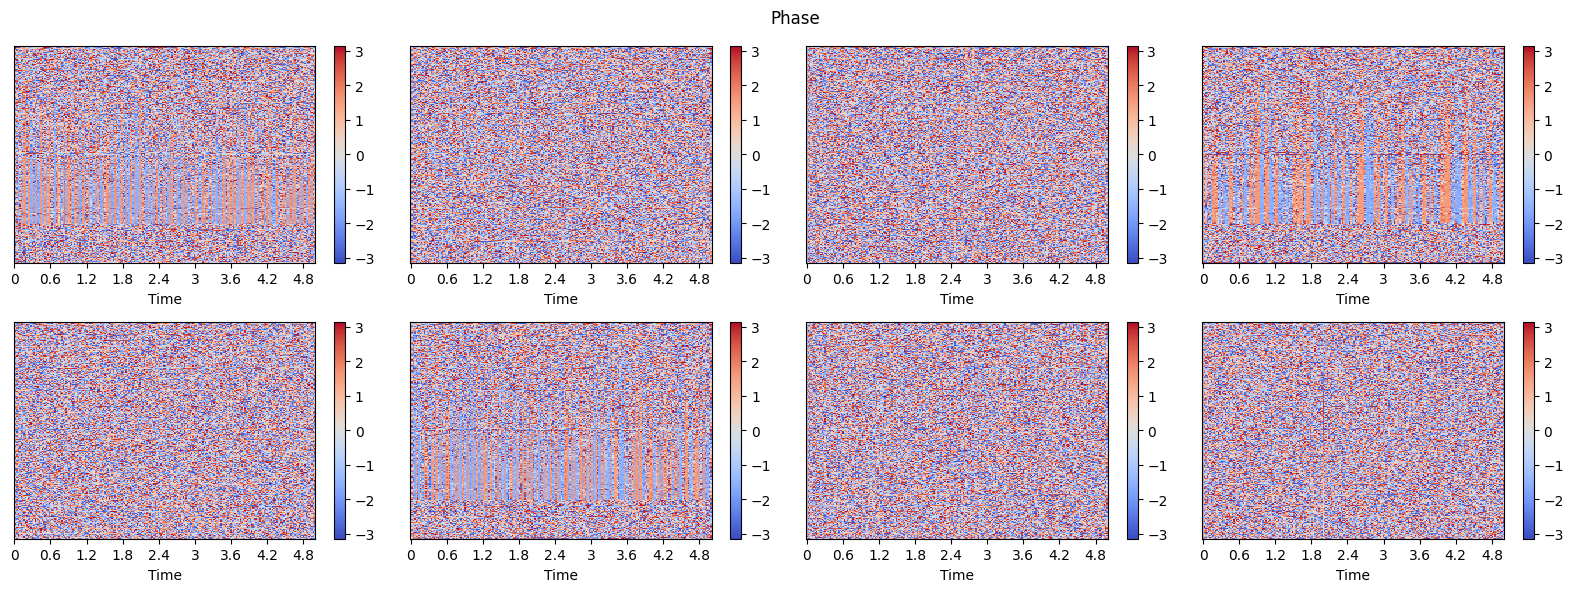

In [23]:
dataset = CombinedAudioDataset(DATA_FOLDER, "all", classes=SELECTED_CLASSES)
plot_features_by_label(dataset, preprocess=True)